In [2]:
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd
from snewpy.models.ccsn import Nakazato_2013, Bollig_2016
from snewpy.neutrino import Flavor, MassHierarchy
from snewpy.flavor_transformation import NoTransformation, AdiabaticMSW
import uproot
from scipy.stats import gaussian_kde

/Users/jacob/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [6]:
supernova_paths = [
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Fornax_No_Oscillations_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Fornax_Normal_Hierarchy_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Fornax_Inverted_Hierarchy_1000_events.root",
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Sukhbold_No_Oscillations_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Sukhbold_Normal_Hierarchy_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Sukhbold_Inverted_Hierarchy_1000_events.root",
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Nakazato_No_Oscillations_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Nakazato_Normal_Hierarchy_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Nakazato_Inverted_Hierarchy_1000_events.root",
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Bollig_No_Oscillations_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Bollig_Normal_Hierarchy_1_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Bollig_Inverted_Hierarchy_1_1000_events.root",
]

# Labels for legend
labels = [
    "No Oscillations - Fornax Model",
    # "Normal Hierarchy - Fornax Model",
    # "Inverted Hierarchy - Fornax Model",
    "No Oscillations - Sukhbold Model",
    # "Normal Hierarchy - Sukhbold Model",
    # "Inverted Hierarchy - Sukhbold Model",
    "No Oscillations - Nakazato Model",
    # "Normal Hierarchy - Nakazato Model",
    # "Inverted Hierarchy - Nakazato Model",
    "No Oscillations - Bollig Model",
    # "Normal Hierarchy - Bollig Model",
    # "Inverted Hierarchy - Bollig Model",
]

# Colors for each dataset
colors_supernova = [
    "#0072B2",  # blue
    "#D55E00",  # reddish orange
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    "#F0E442",  # yellow
    "#56B4E9",  # light blue
]

In [7]:
background_paths = [
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Ar39.root",
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Ar42.root",
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Bi214.root",
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Co60.root",
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_K40.root",
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_K42.root",
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Kr85.root",
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Pb214.root",
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Po210.root",
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Rn222.root",
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Rn220.root",
    "/Volumes/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Rn219.root"
]


labels_background = [
    "Ar39",
    "Ar42",
    "Bi214",
    "Co60",
    "K40",
    "K42",
    "Kr85",
    "Pb214",
    "Po210",
    "Rn222",
    "Rn220",
    "Rn219"
]

colors_background = [
    "#332288",  #  1 deep blue
    "#88CCEE",  #  2 light cyan
    "#44AA99",  #  3 teal
    "#117733",  #  4 dark green
    "#999933",  #  5 olive
    "#DDCC77",  #  6 sand
    "#CC6677",  #  7 muted red
    "#882255",  #  8 wine
    "#AA4499",  #  9 magenta
    "#DDDDDD",  # 10 light gray
    "#E69F00",  # 11 orange
    "#56B4E9",  # 12 sky blue
]

In [8]:
background_data = {}
bg_events_data = {}

for path, label in zip(background_paths, labels_background):
    file = uproot.open(path)
    tree = file["G4_Photons"]

    photon_times = tree["photon_hit_t"].array(library="np")
    
    # Flatten
    all_times = np.concatenate(photon_times)

    # Clean
    mask = (all_times > 0) & (all_times < 1e10)
    clean = all_times[mask]

    # Convert ns → s
    clean_s = clean / 1e9

    print(len(clean_s), "photons in", label)

    background_data[label] = clean_s

1054351 photons in Ar39
65061 photons in Ar42
9520197 photons in Bi214
295088 photons in Co60
1310703 photons in K40
535412 photons in K42
1218116 photons in Kr85
2418823 photons in Pb214
14835 photons in Po210
6556873 photons in Rn222
7624946 photons in Rn220
8743272 photons in Rn219


In [9]:
supernova_data = {}

for path, label in zip(supernova_paths, labels):
    file = uproot.open(path)
    tree = file["G4_Photons"]

    photon_times = tree["photon_hit_t"].array(library="np")

    # Flatten
    all_times = np.concatenate(photon_times)

    # Clean
    mask = (all_times > 0) & (all_times < 1e10)
    clean = all_times[mask]

    # Convert ns → s
    clean_s = clean / 1e9

    print(len(clean_s), "photons in", label)

    supernova_data[label] = clean_s

339249400 photons in No Oscillations - Fornax Model
194632903 photons in No Oscillations - Sukhbold Model
183385177 photons in No Oscillations - Nakazato Model
189308339 photons in No Oscillations - Bollig Model


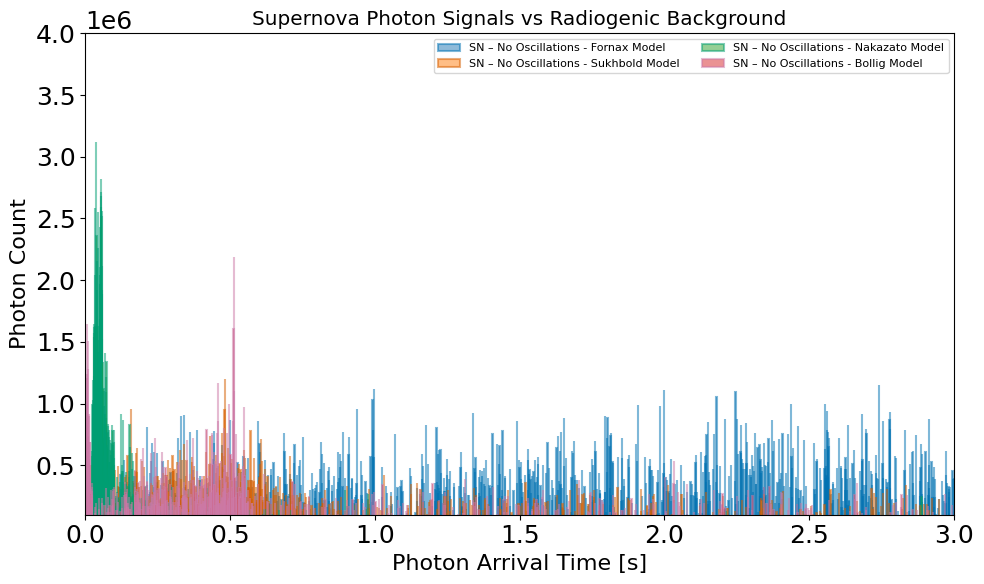

In [29]:
bin_width = 0.0005
bins = np.arange(0, 3 + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

plt.figure(figsize=(10, 6))
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 16,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 12,
    "legend.title_fontsize": 14
})

# ---- 1) Stacked background in absolute photon counts ----
bg_counts_list = []
for label_bg, color_bg in zip(labels_background, colors_background):
    data_bg = background_data[label_bg]
    counts_bg, _ = np.histogram(data_bg, bins=bins)
    bg_counts_list.append(counts_bg)

# bottom = np.zeros_like(bg_counts_list[0], dtype=float)
# for counts_bg, label_bg, color_bg in zip(bg_counts_list, labels_background, colors_background):
#     plt.bar(
#         bin_centers,
#         counts_bg,
#         width=bin_width,
#         bottom=bottom,
#         color=color_bg,
#         alpha=0.35,
#         edgecolor="black",
#         linewidth=0.7,
#         label=label_bg,
#     )
#     bottom += counts_bg

# ---- 2) All supernova models in absolute counts (lines) ----
for label_sn, color_sn in zip(labels, colors_supernova):
    data_sn = supernova_data[label_sn]
    counts_sn, _ = np.histogram(data_sn, bins=bins)
    plt.bar(
        bin_centers,
        counts_sn,
        width=bin_width,
        alpha=0.5,      # no fill
        edgecolor=color_sn,    # colored outline
        linewidth=1.5,
        label=f"SN – {label_sn}",
    )

plt.xlabel("Photon Arrival Time [s]")
plt.ylabel(f"Photon Count")
plt.title("Supernova Photon Signals vs Radiogenic Background")
plt.ylim(1e5, 0.4e7)
plt.xlim(0,3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

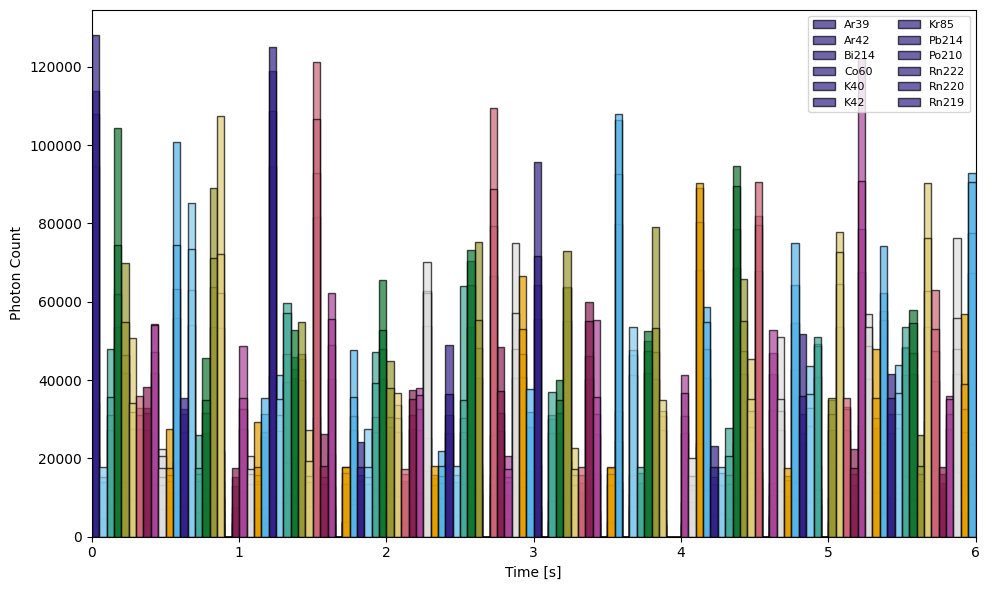

In [19]:
bin_width = 0.005
bins = np.arange(0, 3 + bin_width, bin_width)
bin_centers_bg = 0.5 * (bins[:-1] + bins[1:])


plt.figure(figsize=(10, 6))


for label_bg, color in zip(labels_background, colors_background):
    data_bg = background_data[label_bg]

    counts_bg, bin_edges  = np.histogram(data_bg, bins=bins)

    # if counts_bg.max() > 0:
    #     counts_bg_norm = counts_bg / counts_bg.max()
    # else:
    #     counts_bg_norm = counts_bg

    plt.bar(
        bin_centers_bg,
        counts_bg,
        width=bin_width,
        color=colors_background,
        alpha=0.7,
        edgecolor="black",
        linewidth=1.0,
        label=label_bg,
    )

plt.xlabel("Time [s]")
plt.ylabel("Photon Count")
# plt.ylim(0,2e4)
# plt.yscale("log")
plt.legend(ncol=2, fontsize=8)
plt.xlim(0,3)
plt.tight_layout()
plt.show()